# Use regressions to study relationships

## Setup

In [1]:
# prompt: import basic data science libraries, including statmodels and plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import plotly.express as px


In [2]:
# prompt: install and import stargazer

!pip install stargazer -q
from stargazer.stargazer import Stargazer


In [3]:
# prompt: install and import forestplot

!pip install forestplot -q

import forestplot as fp


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


## Import data

In [4]:
# prompt: import data frame from https://github.com/quarcs-lab/data-open/raw/master/isds/weightHeight.csv

df = pd.read_csv('https://github.com/quarcs-lab/data-open/raw/master/isds/weightHeight.csv')
print(df.head())


  Gender Age group    Height     Weight
0   Male     Adult  1.823847  85.948370
1   Male   Elderly  1.767137  79.694235
2   Male     Adult  1.738435  79.410974
3   Male     Adult  1.719890  62.451094
4   Male     Child  1.602148  69.042020


## Transform variables

In [5]:
# prompt: based on the current categorical variable Gender, create binary (0 or 1) variable

# Create binary variable for Gender
df['Gender_male'] = df['Gender'].map({'Male': 1, 'Female': 0})
print(df.head())


  Gender Age group    Height     Weight  Gender_male
0   Male     Adult  1.823847  85.948370            1
1   Male   Elderly  1.767137  79.694235            1
2   Male     Adult  1.738435  79.410974            1
3   Male     Adult  1.719890  62.451094            1
4   Male     Child  1.602148  69.042020            1


## Visualize regression lines

In [6]:
# prompt: create plotly scatterplot including regression line for Y= Weight and X = Height

# Fit a linear regression model
X = df['Height']
y = df['Weight']
X = sm.add_constant(X)  # Add a constant for the intercept
model = sm.OLS(y, X).fit()

# Create the Plotly scatter plot
fig = px.scatter(df, x='Height', y='Weight', trendline='ols')

# Customize the layout
fig.update_layout(
    title='Weight vs. Height with Regression Line',
    xaxis_title='Height',
    yaxis_title='Weight'
)

# Show the plot
fig.show()

# Print regression summary (optional)
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                 Weight   R-squared:                       0.121
Model:                            OLS   Adj. R-squared:                  0.112
Method:                 Least Squares   F-statistic:                     13.52
Date:                Wed, 23 Apr 2025   Prob (F-statistic):           0.000385
Time:                        13:04:35   Log-Likelihood:                -384.98
No. Observations:                 100   AIC:                             774.0
Df Residuals:                      98   BIC:                             779.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.1079     18.248      0.170      0.8

In [7]:
# prompt: create plotly scatterplot including regression line for Y= Weight and X = Height. Show a regression line for each gender

import plotly.express as px

# Create the Plotly scatter plot with separate regression lines for each gender
fig = px.scatter(df, x='Height', y='Weight', color='Gender', trendline='ols')

# Customize the layout
fig.update_layout(
    title='Weight vs. Height with Regression Line by Gender',
    xaxis_title='Height',
    yaxis_title='Weight'
)

# Show the plot
fig.show()


## Create regression tables

In [8]:
m1 = smf.ols(formula='Weight ~ Height', data=df).fit()
m2 = smf.ols(formula='Weight ~ Height', data=df[df['Gender'] == 'Male']).fit()
m3 = smf.ols(formula='Weight ~ Height', data=df[df['Gender'] == 'Female']).fit()


In [9]:
reg_table = Stargazer([m1, m2, m3])
reg_table

In [10]:
m4 = smf.ols(formula='Weight ~ Height + Gender', data=df).fit()
m5 = smf.ols(formula='Weight ~ Height + Gender + Height:Gender', data=df).fit()

In [11]:
reg_table = Stargazer([m1, m2, m3, m4, m5])
reg_table

## Visualize coefficient plots

In [12]:
# Extract Results and Combine into One DataFrame ---

def extract_results(results, model_name):
    """Helper function to extract params and CIs, and add model name."""
    params = results.params
    conf = results.conf_int() # Gets 95% CI
    conf['estimate'] = params # Add coefficients
    conf = conf.rename(columns={0: 'll', 1: 'hl'}) # Rename CI cols for forestplot
    conf['model'] = model_name
    conf = conf.reset_index().rename(columns={'index': 'varlabel'}) # Make var name a column
    # Exclude intercept for plotting
    #conf = conf[conf['varlabel'] != 'Intercept']
    return conf

In [13]:
# Extract results from each model
df1 = extract_results(m1, 'Model 1 (Total)')
df2 = extract_results(m2, 'Model 2 (Males)')
df3 = extract_results(m3, 'Model 3 (Females)')

In [14]:
# Combine into a single DataFrame
combined_df = pd.concat([df1, df2, df3], ignore_index=True)
combined_df

,varlabel,ll,hl,estimate,model
0,Intercept,-33.104418,39.320242,3.107912,Model 1 (Total)
1,Height,18.273063,61.110212,39.691638,Model 1 (Total)
2,Intercept,33.926899,151.375241,92.651070,Model 2 (Males)
3,Height,-42.824680,24.209460,-9.307610,Model 2 (Males)
4,Intercept,-41.238826,74.210882,16.486028,Model 3 (Females)
5,Height,-6.364091,64.593931,29.114920,Model 3 (Females)


In [16]:
# Define the order you want the models to appear in the plot
model_order = ['Model 1 (Total)', 'Model 2 (Males)', 'Model 3 (Females)']
# Define the order you want the variables to appear
variable_order = ['Height', 'Intercept'] # Include all potential vars


In [17]:
# Filter the combined DataFrame to only include variables we want to plot and ensure the variable order is respected.
# Using pd.Categorical helps enforce the order in the plot.
combined_df['varlabel'] = pd.Categorical(combined_df['varlabel'], categories=variable_order, ordered=True)
combined_df = combined_df.dropna(subset=['varlabel']).sort_values(by=['varlabel', 'model'])


In [18]:
combined_df

,varlabel,ll,hl,estimate,model
1,Height,18.273063,61.110212,39.691638,Model 1 (Total)
3,Height,-42.824680,24.209460,-9.307610,Model 2 (Males)
5,Height,-6.364091,64.593931,29.114920,Model 3 (Females)
0,Intercept,-33.104418,39.320242,3.107912,Model 1 (Total)
2,Intercept,33.926899,151.375241,92.651070,Model 2 (Males)
4,Intercept,-41.238826,74.210882,16.486028,Model 3 (Females)


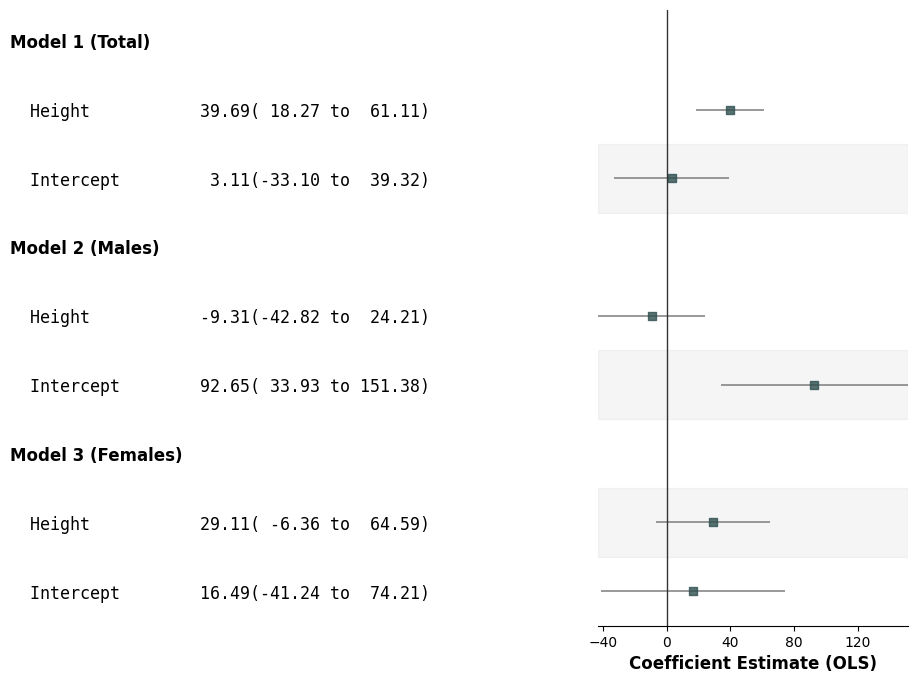

In [19]:
fp.forestplot(
    dataframe=combined_df,             # 📑 DataFrame containing estimates and CIs
    estimate="estimate",               # 🎯 Column name for point estimates
    varlabel="varlabel",               # 🏷️ Column name for variable labels (y-axis)
    ll="ll",                           # 🔽 Column name for lower CI bounds
    hl="hl",                           # 🔼 Column name for upper CI bounds
    groupvar="model",                  # 👥 Column to group observations by model
    group_order=model_order,           # 🔢 List specifying order of models in plot
    color_alt_rows=True,               # 🎨 Enable alternating row colors for clarity
    xlabel="Coefficient Estimate (OLS)"# ➡️ Label for the x-axis
);

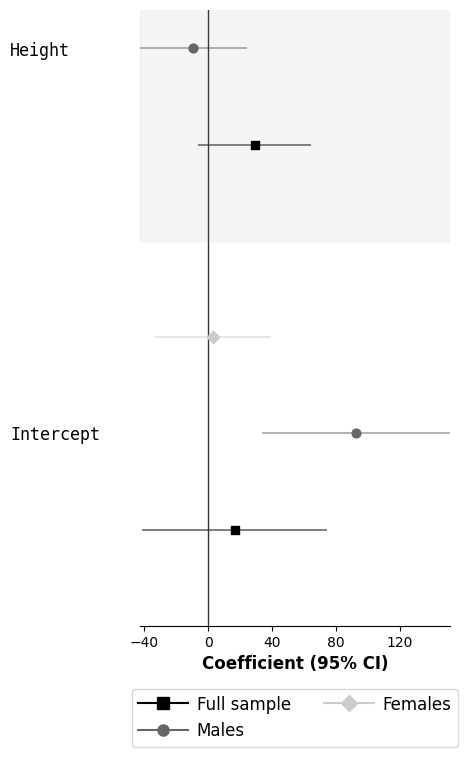

In [20]:
fp.mforestplot(
    dataframe=combined_df,
    estimate="estimate",
    ll="ll",
    hl="hl",
    varlabel="varlabel",
    model_col="model",
    group_order=model_order,
    figsize=(4, 8),
    color_alt_rows=True,
    xlabel="Coefficient (95% CI)",
    modellabels=["Full sample", "Males", "Females"]);

Learn more about the forestplot here:
-  https://pypi.org/project/forestplot/
- https://colab.research.google.com/drive/1h8LOXMIlguDONetXSouw4S2dcYZimpHy?usp=sharing
